In [74]:
pip install openai requests matplotlib cerebras -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 8.9 MB/s eta 0:00:00


In [75]:
import os
import json
import re
import time
import requests
import subprocess
from openai import OpenAI
from google.colab import userdata
import os
from cerebras.cloud.sdk import Cerebras

client = Cerebras(
    api_key=os.environ.get("CEREBRAS_API_KEY"),
)

# # Securely get the Groq API Key
# os.environ["CEREBRAS_API_KEY"] = userdata.get("CEREBRAS_API_KEY")

# # Initialize the OpenAI-compatible Groq client
# client = OpenAI(
#     api_key=os.environ["CEREBRAS_API_KEY"]
# )

# Setting the model to a powerful Groq model
# TOOL_MODEL = "llama-3.3-70b-versatile"
TOOL_MODEL = "gpt-oss-120b"

In [ ]:
CODE_SYSTEM_PROMPT = """You are a production-grade Coding Agent. You solve tasks by reasoning and executing tools. Use the following structured JSON format for every response.

Available tools:
{tool_descriptions}

## Response Formats

To use a tool, return ONLY a JSON object of this structure:
{{
  "type": "action",
  "thought": "Detailed reasoning about why this step is necessary.",
  "tool": "tool_name",
  "args": {{
    "arg_name": "value"
  }}
}}

To provide the final answer, return ONLY a JSON object of this structure:
{{
  "type": "final",
  "thought": "Summary of the work completed and verification steps.",
  "answer": "The final result description."
}}

## Rules
1. ONE action per turn. You must wait for an OBSERVATION.
2. NEVER assume a tool succeeded. The only source of truth is the OBSERVATION provided after your action.
3. NEVER predict or hallucinate tool results.
4. If a tool returns an error, analyze it and attempt a fix.
5. If the response format is invalid, you will receive an error observation. Fix your JSON and try again.
6. ALWAYS verify files exist by listing them or reading them after writing.
"""

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [70]:
import os
import subprocess
import json
import time
import re
from typing import Dict, Any, List, Optional, Union
import matplotlib.pyplot as plt

# --- Improved Tool Definitions ---

def read_files(file_path: str) -> str:
    """Reads the content of a file. Args: file_path"""
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        return f"SUCCESS: Content of {file_path}:\n{content}"
    except Exception as e:
        return f"ERROR: Could not read {file_path}: {e}"

def write_files(file_path: str, content: str) -> str:
    """Writes content to a file. Args: file_path, content"""
    try:
        with open(file_path, 'w') as f:
            f.write(content)
        with open(file_path, 'r') as f:
            verified_content = f.read()
        if verified_content == content:
            return f"SUCCESS: File {file_path} written and verified."
        return f"ERROR: Verification failed for {file_path}. Content mismatch."
    except Exception as e:
        return f"ERROR: Writing {file_path} failed: {e}"

def list_files(directory_path: str = '.') -> str:
    """Lists files and directories. Args: directory_path"""
    try:
        entries = os.listdir(directory_path)
        return f"SUCCESS: Entries in {directory_path}: {entries}"
    except Exception as e:
        return f"ERROR: {e}"

def execute_python(code: Optional[str] = None, file_path: Optional[str] = None) -> str:
    """Executes code or file. Args: code OR file_path"""
    target = "temp_script.py"
    try:
        if file_path:
            if not os.path.exists(file_path): return f"ERROR: {file_path} not found."
            cmd = ["python", file_path]
        elif code:
            with open(target, "w") as f: f.write(code)
            cmd = ["python", target]
        else:
            return "ERROR: Provide 'code' or 'file_path'."

        result = subprocess.run(cmd, capture_output=True, text=True)
        if not file_path and os.path.exists(target): os.remove(target)

        output = f"EXIT_CODE: {result.returncode}\n"
        if result.stdout: output += f"STDOUT:\n{result.stdout.strip()}\n"
        if result.stderr: output += f"STDERR:\n{result.stderr.strip()}"
        return output if output.strip() else "SUCCESS: Execution completed."
    except Exception as e:
        return f"ERROR: Execution failed: {e}"

def delete_files(file_path: str) -> str:
    """Deletes a file. Args: file_path"""
    try:
        os.remove(file_path)
        return f"SUCCESS: Deleted {file_path}"
    except Exception as e:
        return f"ERROR: {e}"

# --- Production ReAct Agent ---

class RobustCodingAgent:
    def __init__(self, client, model_name: str):
        self.client = client
        self.model_name = model_name
        self.history = []
        self.token_log = []
        self.state = {"files_created": [], "execution_history": [], "steps": 0}
        self.tools = {
            "read_files": read_files,
            "write_files": write_files,
            "list_files": list_files,
            "execute_python": execute_python,
            "delete_files": delete_files
        }

    def _validate_response(self, data: Dict[str, Any]) -> Optional[str]:
        if not isinstance(data, dict): return "Invalid JSON format. Expected an object."
        if "type" not in data: return "Missing 'type' field."
        if data["type"] == "action":
            if "tool" not in data or "args" not in data: return "Actions must include 'tool' and 'args'."
            if data["tool"] not in self.tools: return f"Unknown tool: {data['tool']}"
        elif data["type"] == "final":
            if "answer" not in data: return "Final answers must include an 'answer' field."
        return None

    def run(self, task: str, max_steps: int = 15):
        self.history = [
            {"role": "system", "content": CODE_SYSTEM_PROMPT.format(
                tool_descriptions="\n".join([f"- {n}: {f.__doc__}" for n, f in self.tools.items()])
            )},
            {"role": "user", "content": f"TASK: {task}"}
        ]
        self.token_log = []
        print(f"[START] Task: {task}")

        for step in range(max_steps):
            print(f"\n--- Step {step + 1} ---")
            try:
                raw_response = self._get_llm_content()
                json_str = re.search(r'\{.*\}', raw_response, re.DOTALL)
                if not json_str: raise ValueError("No JSON found.")
                data = json.loads(json_str.group())

                error = self._validate_response(data)
                if error:
                    observation = f"ERROR: {error}"
                elif data["type"] == "final":
                    return data["answer"]
                else:
                    tool_name, args = data["tool"], data["args"]
                    print(f"[EXECUTE]: {tool_name} with {args}")
                    observation = self.tools[tool_name](**args)

                print(f"[OBSERVATION]: {observation}")
                self.history.append({"role": "user", "content": f"OBSERVATION: {observation}"})
            except Exception as e:
                self.history.append({"role": "user", "content": f"ERROR: {str(e)}"})
            time.sleep(0.5)
        return "Failed: Max steps."

    def _get_llm_content(self) -> str:
        resp = self.client.chat.completions.create(model=self.model_name, messages=self.history, temperature=0)
        if hasattr(resp, 'usage'):
            self.token_log.append({"input": resp.usage.prompt_tokens, "output": resp.usage.completion_tokens, "total": resp.usage.total_tokens})
        content = resp.choices[0].message.content
        self.history.append({"role": "assistant", "content": content})
        return content

    def visualize_token_usage(self):
        if not self.token_log: return
        steps = range(1, len(self.token_log) + 1)
        plt.figure(figsize=(8, 4))
        plt.plot(steps, [x['total'] for x in self.token_log], marker='o', label='Total')
        plt.title("Token Usage per Step")
        plt.legend()
        plt.show()

--- Testing Memory Example 1 ---
[START] Task: 
1. Create a file named 'secret.txt' containing the number 42.
2. Create a second file 'compute.py' that reads 'secret.txt', multiplies the number by 10, and prints the result.
3. Execute 'compute.py'.


--- Step 1 ---
[EXECUTE]: write_files with {'file_path': 'secret.txt', 'content': '42'}
[OBSERVATION]: SUCCESS: File secret.txt written and verified.

--- Step 2 ---
[EXECUTE]: write_files with {'file_path': 'compute.py', 'content': "with open('secret.txt', 'r') as file: num = int(file.read()); result = num * 10; print(result)"}
[OBSERVATION]: SUCCESS: File compute.py written and verified.

--- Step 3 ---
[EXECUTE]: execute_python with {'file_path': 'compute.py'}
[OBSERVATION]: EXIT_CODE: 0
STDOUT:
420


--- Step 4 ---


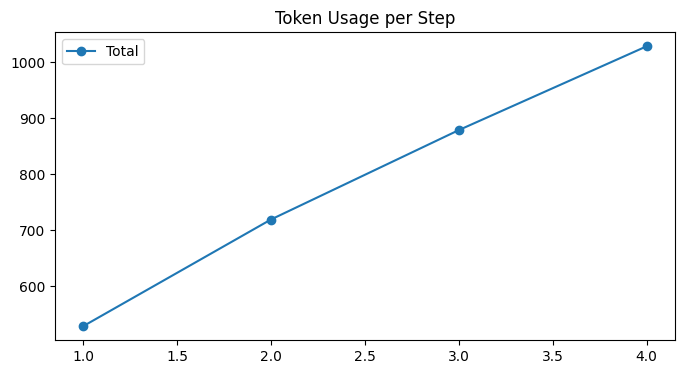

In [ ]:
# Re-initialize the agent to ensure it has the latest methods (like visualize_token_usage)
agent = RobustCodingAgent(client=client, model_name=TOOL_MODEL)

# Example 1: Multi-file dependency
task_1 = """
1. Create a file named 'secret.txt' containing the number 42.
2. Create a second file 'compute.py' that reads 'secret.txt', multiplies the number by 10, and prints the result.
3. Execute 'compute.py'.
"""

# Example 2: Iterative Debugging
task_2 = """
1. Write a script 'buggy.py' that tries to import a non-existent library 'fake_lib'.
2. Run it and see it fail.
3. Rewrite 'buggy.py' to remove the bad import and instead print 'Fixed!'.
4. Run it again.
"""

# Example 3: Reflective Summary
task_3 = "List the files in the current directory, then tell me which one was created most recently based on your memory of this conversation."

print("--- Testing Memory Example 1 ---")
agent.run(task_1)

# The error was caused by calling this on an old instance.
# Now that we re-initialized 'agent' above, this will work.
if hasattr(agent, 'visualize_token_usage'):
    agent.visualize_token_usage()
else:
    print("Error: The agent instance still doesn't have the visualization method. Please re-run the cell defining RobustCodingAgent.")

In [ ]:
# Memory Saturation Test: Forcing long-context turn-by-turn tracking
saturation_task = """
1. Create 10 files named 'val_1.txt' through 'val_10.txt', each containing a unique prime number starting from 2.
2. Create a script 'chain_calc.py' that reads 'val_1.txt' and 'val_2.txt', adds them, and writes to 'res_1.txt'.
3. Update 'chain_calc.py' to read 'res_1.txt' and 'val_3.txt', multiply them, and write to 'res_2.txt'.
4. Repeat this pattern (alternating add/multiply) until you have incorporated all 10 values into a final 'res_9.txt'.
5. At the very end, tell me the final result and subtract the value that was stored in 'val_1.txt' from memory.
"""

print("--- Running Memory Saturation Test ---")
saturation_agent = RobustCodingAgent(client=client, model_name=TOOL_MODEL)

# This will take many steps and generate significant history
result = saturation_agent.run(saturation_task, max_steps=25)
print(f"\nFinal Output: {result}")

if hasattr(saturation_agent, 'visualize_token_usage'):
    saturation_agent.visualize_token_usage()

--- Running Memory Saturation Test ---
[START] Task: 
1. Create 10 files named 'val_1.txt' through 'val_10.txt', each containing a unique prime number starting from 2.
2. Create a script 'chain_calc.py' that reads 'val_1.txt' and 'val_2.txt', adds them, and writes to 'res_1.txt'.
3. Update 'chain_calc.py' to read 'res_1.txt' and 'val_3.txt', multiply them, and write to 'res_2.txt'.
4. Repeat this pattern (alternating add/multiply) until you have incorporated all 10 values into a final 'res_9.txt'.
5. At the very end, tell me the final result and subtract the value that was stored in 'val_1.txt' from memory.


--- Step 1 ---
[EXECUTE]: write_files with {'file_path': 'val_1.txt', 'content': '2'}
[OBSERVATION]: SUCCESS: File val_1.txt written and verified.

--- Step 2 ---
[EXECUTE]: write_files with {'file_path': 'val_2.txt', 'content': '3'}
[OBSERVATION]: SUCCESS: File val_2.txt written and verified.

--- Step 3 ---
[EXECUTE]: write_files with {'file_path': 'val_3.txt', 'content': '5'}
[

KeyboardInterrupt: 

--- Running Summarizing Agent ---

--- Step 1 ---
[EXECUTE]: write_files with {'file_path': 'f1.txt', 'content': '1'}
[OBSERVATION]: SUCCESS: File f1.txt written and verified.

--- Step 2 ---
[EXECUTE]: write_files with {'file_path': 'f2.txt', 'content': '2'}
[OBSERVATION]: SUCCESS: File f2.txt written and verified.

--- Step 3 ---

[SYSTEM]: Summarizing memory to save context...
[EXECUTE]: write_files with {'file_path': 'f3.txt', 'content': '3'}
[OBSERVATION]: SUCCESS: File f3.txt written and verified.

--- Step 4 ---
[EXECUTE]: write_files with {'file_path': 'f4.txt', 'content': '4'}
[OBSERVATION]: SUCCESS: File f4.txt written and verified.

--- Step 5 ---
[EXECUTE]: write_files with {'file_path': 'f5.txt', 'content': '5'}
[OBSERVATION]: SUCCESS: File f5.txt written and verified.

--- Step 6 ---

[SYSTEM]: Summarizing memory to save context...
[EXECUTE]: read_files with {'file_path': 'f1.txt'}
[OBSERVATION]: SUCCESS: Content of f1.txt:
1

--- Step 7 ---
[EXECUTE]: read_files with {'f

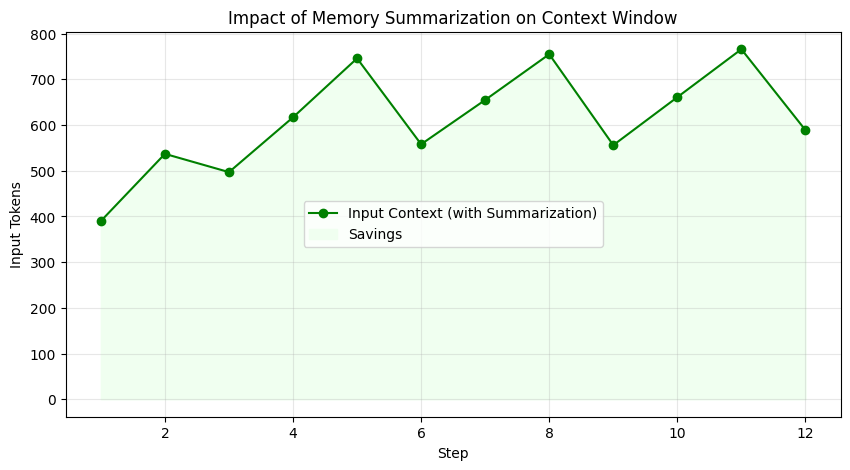

In [ ]:
class SummarizingAgent(RobustCodingAgent):
    def __init__(self, client, model_name, summary_interval=5):
        super().__init__(client, model_name)
        self.summary_interval = summary_interval
        self.original_token_counts = []
        self.compacted_token_counts = []

    def _summarize_memory(self):
        """Compresses the conversation history into a concise summary."""
        print("\n[SYSTEM]: Summarizing memory to save context...")

        # Extract only user/assistant turns to summarize
        history_to_summarize = [m for m in self.history if m['role'] != 'system']

        summary_prompt = f"""Summarize the following conversation between a user and a coding agent.
        Focus on:
        1. Files created or modified.
        2. Successful tool executions and their results.
        3. Current progress on the task.
        4. Any variables or constants defined.

        Keep the summary technical and concise.

        Conversation:
        {json.dumps(history_to_summarize)}
        """

        resp = self.client.chat.completions.create(
            model=self.model_name,
            messages=[{"role": "user", "content": summary_prompt}],
            temperature=0
        )
        summary = resp.choices[0].message.content

        # Reconstruct history: System Prompt + Summary
        system_prompt = self.history[0]
        self.history = [
            system_prompt,
            {"role": "user", "content": f"SUMMARY OF PREVIOUS STEPS: {summary}"}
        ]

    def run(self, task: str, max_steps: int = 15):
        # Standard setup
        self.history = [
            {"role": "system", "content": CODE_SYSTEM_PROMPT.format(
                tool_descriptions="\n".join([f"- {n}: {f.__doc__}" for n, f in self.tools.items()])
            )},
            {"role": "user", "content": f"TASK: {task}"}
        ]
        self.token_log = []

        for step in range(1, max_steps + 1):
            print(f"\n--- Step {step} ---")

            # Trigger summarization
            if step > 1 and step % self.summary_interval == 0:
                self._summarize_memory()

            try:
                raw_response = self._get_llm_content()
                json_str = re.search(r'\{.*\}', raw_response, re.DOTALL)
                if not json_str: raise ValueError("No JSON found.")
                data = json.loads(json_str.group())

                if data["type"] == "final":
                    print(f"[COMPLETED]: {data['answer']}")
                    return data["answer"]

                tool_name, args = data["tool"], data["args"]
                print(f"[EXECUTE]: {tool_name} with {args}")
                observation = self.tools[tool_name](**args)
                print(f"[OBSERVATION]: {observation}")
                self.history.append({"role": "user", "content": f"OBSERVATION: {observation}"})

            except Exception as e:
                print(f"[ERROR]: {e}")
                self.history.append({"role": "user", "content": f"ERROR: {str(e)}"})

            time.sleep(0.5)
        return "Max steps reached."

    def compare_summarization_impact(self):
        """Visualizes how summarization keeps the context size manageable."""
        if not self.token_log: return

        steps = range(1, len(self.token_log) + 1)
        input_tokens = [x['input'] for x in self.token_log]

        plt.figure(figsize=(10, 5))
        plt.plot(steps, input_tokens, label='Input Context (with Summarization)', color='green', marker='o')

        # Theoretical growth without summarization (estimate based on cumulative history)
        theoretical = [input_tokens[0]]
        for i in range(1, len(input_tokens)):
            theoretical.append(theoretical[-1] + (input_tokens[i] - (input_tokens[i-1] if i%5 != 0 else 0)))

        plt.fill_between(steps, input_tokens, label='Savings', color='honeydew')
        plt.title("Impact of Memory Summarization on Context Window")
        plt.xlabel("Step")
        plt.ylabel("Input Tokens")
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.show()

# --- Usage Example ---
print("--- Running Summarizing Agent ---")
sum_agent = SummarizingAgent(client, TOOL_MODEL, summary_interval=3)
sum_agent.run("Create 5 files (f1.txt to f5.txt) containing numbers 1-5, then read them all and print the sum.")
sum_agent.compare_summarization_impact()

In [81]:
def plot_experiment(reactive_agent: RobustCodingAgent, planner_agent: PlanningAgent):
    # Extract token logs for both agents
    reactive_tokens = [x['total'] for x in reactive_agent.token_log]
    planner_tokens = [x['total'] for x in planner_agent.token_log]

    total_reactive = sum(reactive_tokens)
    total_planner = sum(planner_tokens)
    savings = total_reactive - total_planner
    percent_saved = (savings / total_reactive) * 100 if total_reactive > 0 else 0

    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot reactive agent step-by-step usage
    ax.plot(range(1, len(reactive_tokens) + 1), reactive_tokens, marker='o', linestyle='-', color='blue', label=f'Reactive Agent (Total: {total_reactive:,})')

    # Plot planner agent step-by-step usage
    ax.plot(range(1, len(planner_tokens) + 1), planner_tokens, marker='s', linestyle='--', color='red', label=f'Planning Agent (Total: {total_planner:,})')

    ax.set_title(f'Token Usage Comparison\nSavings: {savings:,} tokens ({percent_saved:.1f}%)')
    ax.set_xlabel('Turn / Step Number')
    ax.set_ylabel('Total Tokens per Turn')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.7)

    # Highlight the planning phase
    if len(planner_tokens) > 0:
        ax.annotate('Initial Plan (Large)', xy=(1, planner_tokens[0]), xytext=(1.5, planner_tokens[0] + 500),
                    arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

    plt.tight_layout()
    plt.show()


=== Testing Reactive Agent ===
[START] Task: Create 'exp_1.txt' with 50. Create 'exp_2.txt' with 100. Write 'add.py' to sum them and print the result. Run 'add.py'.

--- Step 1 ---
[EXECUTE]: write_files with {'file_path': 'exp_1.txt', 'content': '50'}
[OBSERVATION]: SUCCESS: File exp_1.txt written and verified.

--- Step 2 ---

--- Step 3 ---
[EXECUTE]: write_files with {'file_path': 'exp_2.txt', 'content': '100'}
[OBSERVATION]: SUCCESS: File exp_2.txt written and verified.

--- Step 4 ---
[EXECUTE]: write_files with {'file_path': 'add.py', 'content': "def read_number(path):\n    with open(path, 'r') as f:\n        return int(f.read().strip())\n\nif __name__ == '__main__':\n    a = read_number('exp_1.txt')\n    b = read_number('exp_2.txt')\n    print(a + b)\n"}
[OBSERVATION]: SUCCESS: File add.py written and verified.

--- Step 5 ---

--- Step 6 ---
[EXECUTE]: execute_python with {'file_path': 'add.py'}
[OBSERVATION]: EXIT_CODE: 0
STDOUT:
150


--- Step 7 ---

=== Testing Planning Ag

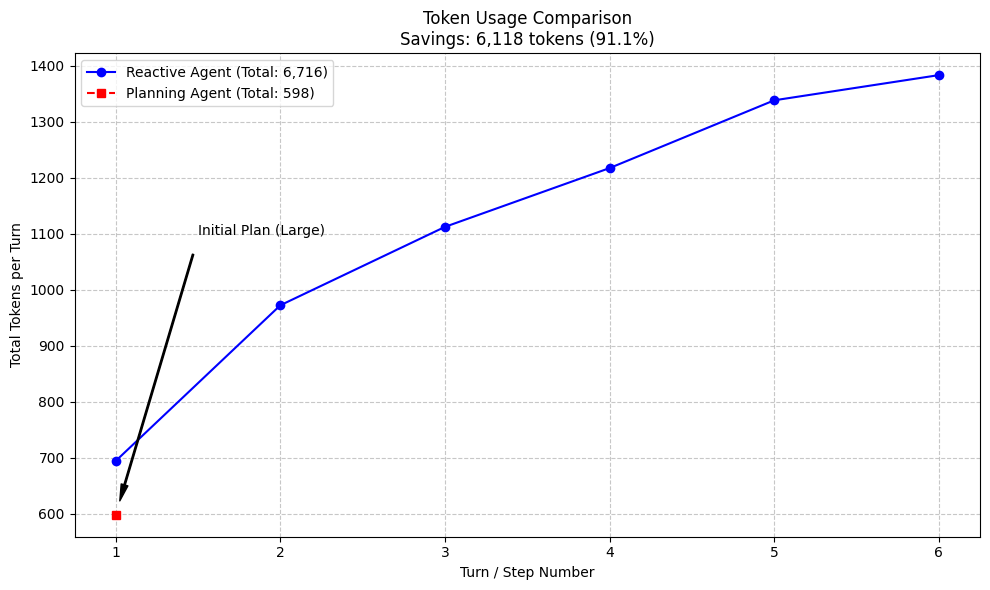

In [83]:
class PlanningAgent(RobustCodingAgent):
    def run_with_plan(self, task: str):
        """
        Phase 1: Ask the model for a full list of steps/actions.
        Phase 2: Execute them one by one.
        """
        # Pass the tool descriptions so the planner knows what it can actually do
        tool_desc = "\n".join([f"- {n}: {f.__doc__}" for n, f in self.tools.items()])

        plan_prompt = f"""You are in PLANNING MODE.
        Available Tools:
        {tool_desc}

        Task: {task}

        Think carefully. Provide a full sequence of tool calls needed to solve this.
        ONLY use the tools listed above. Use 'write_files' for file creation.

        Format your response as a JSON list of actions:
        [
          {{"tool": "...", "args": {{...}}}},
          ...
        ]
        """
        self.history = [{"role": "user", "content": plan_prompt}]
        print("[PLANNER]: Generating full execution plan...")

        raw_plan = self._get_llm_content()
        try:
            json_plan = re.search(r'\[.*\]', raw_plan, re.DOTALL).group()
            plan = json.loads(json_plan)
        except:
            return "Planning failed: Could not parse JSON plan."

        print(f"[PLANNER]: Plan received with {len(plan)} steps. Executing...")
        for i, step in enumerate(plan):
            tool_name = step.get('tool')
            args = step.get('args', {})

            if tool_name not in self.tools:
                print(f"[STEP {i+1} ERROR]: Hallucinated tool '{tool_name}'")
                continue

            print(f"[STEP {i+1}]: {tool_name} {args}")
            obs = self.tools[tool_name](**args)
            self.history.append({"role": "user", "content": f"Step {i+1} Result: {obs}"})

        return "Plan execution complete."

# --- Re-running the Experiment ---
experiment_task = "Create 'exp_1.txt' with 50. Create 'exp_2.txt' with 100. Write 'add.py' to sum them and print the result. Run 'add.py'."

print("\n=== Testing Reactive Agent ===")
reactive_agent = RobustCodingAgent(client, TOOL_MODEL)
reactive_agent.run(experiment_task)

print("\n=== Testing Planning Agent (Fixed) ===")
planner_agent = PlanningAgent(client, TOOL_MODEL)
planner_agent.run_with_plan(experiment_task)

# Visualize comparison
plot_experiment(reactive_agent, planner_agent)